# Segmentación de los bancos chilenos con datos de la CMF

**Pregunta.** ¿Qué grupos de bancos existen en Chile según su solvencia, rentabilidad, riesgo de crédito, eficiencia y modelo de negocio?

**Datos.** Indicadores mensuales por banco publicados por la Comisión para el Mercado Financiero (CMF) en su API BEST, entre agosto de 2025 y julio de 2026. Para ver la evolución en el tiempo se usan además series desde 2019.

**Método.** Se promedia cada indicador en los últimos doce meses, se transforman las variables asimétricas y se estandarizan. Luego se comparan dos métodos de clustering, k-means y jerárquico de Ward, y se elige el número de grupos con el coeficiente de silueta. Los grupos se interpretan con sus perfiles y con un análisis de componentes principales.

**Resultado principal.** El sistema bancario chileno se ordena en tres grupos: la banca universal, que concentra casi todo el crédito, la banca de consumo, con alta rentabilidad y alto costo, y la banca mayorista extranjera, con capital muy holgado y casi sin crédito a personas. Falabella queda en la frontera entre la banca universal y la de consumo, según el método que se use.

## 1. Configuración y datos

In [1]:
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from dsaplicado import cmf, datos
from dsaplicado.graficos import (
    COLORES, DIVERGENTE, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo, eje_porcentaje,
)

aplicar_estilo()
pd.set_option("display.float_format", "{:.2f}".format)

RAIZ = datos.raiz_repositorio()
CACHE = RAIZ / "datos" / "cmf"
FIGURAS = RAIZ / "01_analisis_de_datos" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

INICIO, FIN = date(2025, 8, 1), date(2026, 7, 31)   # ventana de doce meses para el corte transversal
INICIO_HISTORIA = date(2019, 8, 1)

# Cuadros de la API BEST con una serie por banco.
CUADROS = {
    "solvencia": ("CMF_BCOS_IND_BASILEA3_PATEFE_APR_AGIFI_STO_RAZ_PORC_MONT", INICIO_HISTORIA),
    "apalancamiento": ("CMF_BCOS_IND_BASILEA3_CAPBAS_ATR_AGIFI_STO_RAZ_PORC_MONT", INICIO),
    "roae": ("CMF_CONT_RENTAB_ROAE_DESPUES_IMPTOS_AGIFI_STO_RAZ_PORC_MONT", INICIO_HISTORIA),
    "deterioro": ("CMF_CONT_CARDETER_CONSOL_CCA_AGIFI_STO_RAZ_PORC_MONT", INICIO_HISTORIA),
    "morosidad_90": ("CMF_CONT_MOR_90DMAS_CONSOL_COL_AGIFI_STO_RAZ_PORC_MONT", INICIO),
    "provisiones": ("CMF_CONT_RIESGOCRED_PROV_ADIC_CCA_AGIFI_STO_RAZ_PORC_MONT", INICIO),
    "gastos_activos": ("CMF_CONT_EFICOPER_GASTOPER_ACTIVTOT_AGIFI_STO_RAZ_PORC_MONT", INICIO),
    "colocaciones": ("SBIF_CONT_EPLME_ACTIV_COL_AGIFI", INICIO),
    "consumo": ("SBIF_CONT_EPLME_ACTIV_CCS_AGIFI", INICIO),
    "vivienda": ("SBIF_CONT_EPLME_ACTIV_CHV_AGIFI", INICIO),
}

# Los datos quedan en caché. Solo la primera ejecución consulta la API y requiere la clave.
series = {}
for indicador, (tag, desde) in CUADROS.items():
    tabla = cmf.cargar_cuadro(tag, desde, FIN, CACHE)
    tabla["banco"] = tabla["codigo_serie"].map(cmf.codigo_institucion)
    series[indicador] = tabla
    print(f"{indicador:15s} {len(tabla):5d} datos, {tabla['banco'].nunique()} instituciones, "
          f"de {tabla['fecha'].min():%m-%Y} a {tabla['fecha'].max():%m-%Y}")

solvencia         981 datos, 18 instituciones, de 12-2021 a 06-2026
apalancamiento    189 datos, 18 instituciones, de 08-2025 a 06-2026
roae             1447 datos, 18 instituciones, de 08-2019 a 07-2026
deterioro        1394 datos, 19 instituciones, de 08-2019 a 07-2026
morosidad_90      205 datos, 18 instituciones, de 08-2025 a 07-2026
provisiones       205 datos, 18 instituciones, de 08-2025 a 07-2026
gastos_activos    205 datos, 18 instituciones, de 08-2025 a 07-2026
colocaciones      205 datos, 18 instituciones, de 08-2025 a 07-2026
consumo           205 datos, 18 instituciones, de 08-2025 a 07-2026
vivienda          205 datos, 18 instituciones, de 08-2025 a 07-2026


| Indicador | Qué mide |
|---|---|
| solvencia | Patrimonio efectivo sobre activos ponderados por riesgo, el indicador central de Basilea III |
| apalancamiento | Capital básico sobre activos totales, sin ponderar por riesgo |
| roae | Utilidad después de impuestos sobre patrimonio promedio, anualizada |
| deterioro | Cartera deteriorada sobre colocaciones |
| morosidad_90 | Cartera con atraso de 90 días o más sobre colocaciones |
| provisiones | Provisiones por riesgo de crédito, incluidas las adicionales, sobre colocaciones |
| gastos_activos | Gastos operacionales sobre activos totales, una medida de eficiencia |
| colocaciones, consumo, vivienda | Stock de crédito total y por tipo de cartera, en millones de pesos |

## 2. Tabla de indicadores por banco

In [2]:
NOMBRES = {
    "BCHI": "Banco de Chile", "BSANT": "Santander", "BECH": "BancoEstado", "BCI": "BCI", "BSCOT": "Scotiabank",
    "BITAUCORP": "Itaú", "BICE": "BICE", "BSEC": "Security", "BCON": "Consorcio", "BINTE": "Internacional",
    "BFALA": "Falabella", "BRIPL": "Ripley", "BBTGP": "BTG Pactual", "HSBC": "HSBC", "JPMGC": "JP Morgan",
    "BKCH": "Bank of China", "CHCONBANK": "China Construction", "TANNERBD": "Tanner", "SISTBANC": "Sistema bancario",
}

promedios = {}
for indicador, tabla in series.items():
    ventana = tabla[(tabla["fecha"] >= pd.Timestamp(INICIO)) & (tabla["fecha"] <= pd.Timestamp(FIN))]
    promedios[indicador] = ventana.groupby("banco")["valor"].mean()
indicadores = pd.DataFrame(promedios)
indicadores["participacion_consumo"] = 100 * indicadores["consumo"] / indicadores["colocaciones"]
indicadores["participacion_vivienda"] = 100 * indicadores["vivienda"] / indicadores["colocaciones"]
indicadores.index = indicadores.index.map(NOMBRES)

sistema = indicadores.loc["Sistema bancario"]
print("Instituciones sin dato de solvencia:", list(indicadores.index[indicadores["solvencia"].isna()]))
bancos = indicadores.drop(index=["Sistema bancario", "Tanner"])
columnas_tabla = ["solvencia", "apalancamiento", "roae", "deterioro", "morosidad_90", "provisiones",
                  "gastos_activos", "participacion_consumo", "participacion_vivienda"]
bancos.sort_values("colocaciones", ascending=False)[columnas_tabla]

Instituciones sin dato de solvencia: ['Tanner']


,solvencia,apalancamiento,roae,deterioro,morosidad_90,provisiones,gastos_activos,participacion_consumo,participacion_vivienda
banco,,,,,,,,,
Santander,16.56,7.15,23.69,7.22,3.08,3.72,1.44,12.32,43.02
Banco de Chile,17.88,9.74,21.28,3.57,1.62,3.69,2.08,14.39,35.09
BancoEstado,16.72,6.36,12.13,9.38,4.17,5.39,2.29,7.45,48.83
BCI,15.36,8.07,13.95,4.62,1.42,1.99,1.78,8.15,34.47
Scotiabank,17.17,8.79,11.74,6.58,2.74,3.14,1.57,8.01,46.20
Itaú,17.33,7.47,9.46,6.65,2.24,3.10,1.90,11.04,35.50
BICE,16.08,8.33,14.05,4.29,1.26,2.55,1.81,4.61,21.75
Security,15.53,8.54,9.76,7.68,2.11,3.35,2.40,6.54,18.22
Consorcio,21.88,7.71,11.58,7.04,2.35,2.13,0.88,2.23,32.91


**Control de calidad.**

- **Tanner Banco Digital** no reporta indicadores de solvencia ni de rentabilidad en el período, así que queda fuera del análisis.
- **Sistema bancario** es el agregado que publica la CMF. Se usa como referencia, no como observación.
- **Sucursales de bancos extranjeros.** Bank of China, China Construction Bank y JP Morgan tienen carteras de crédito muy pequeñas. Sus ratios de riesgo de crédito se calculan sobre bases minúsculas y deben leerse con cautela.

Quedan 17 bancos para el análisis.

## 3. Solvencia frente al mínimo regulatorio

El mínimo legal de Basilea III en Chile es un patrimonio efectivo de 8% de los activos ponderados por riesgo. A eso se suman colchones de conservación y, para los bancos sistémicos, un cargo adicional.

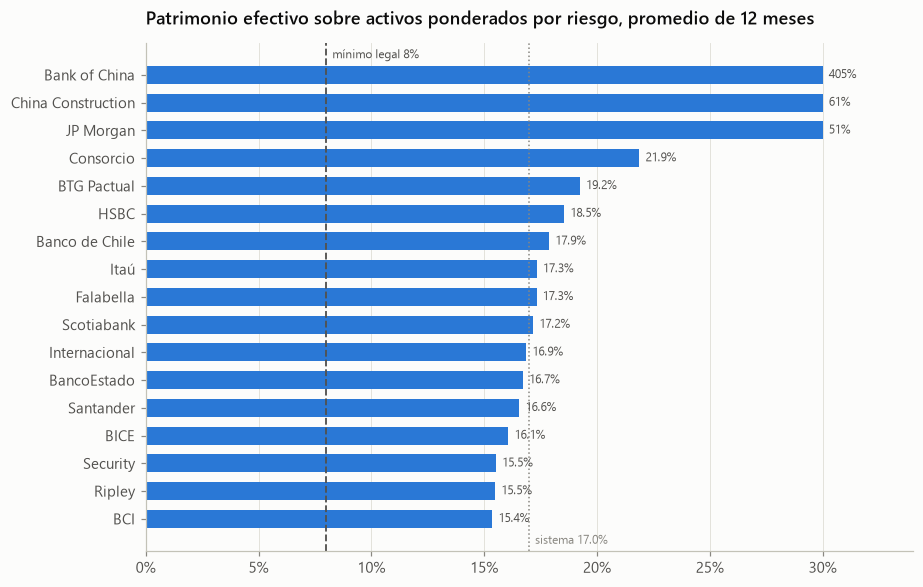

In [3]:
orden = bancos["solvencia"].sort_values()
tope = 30
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(orden.index, orden.clip(upper=tope), color=COLORES[0], height=0.65)
for i, valor in enumerate(orden):
    texto = f"{valor:.0f}%" if valor > tope else f"{valor:.1f}%"
    ax.annotate(texto, (min(valor, tope), i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8,
                color=TINTA_SECUNDARIA)
ax.axvline(8, color=TINTA_SECUNDARIA, linewidth=1.2, linestyle="--")
ax.annotate("mínimo legal 8%", (8, len(orden) - 0.4), xytext=(4, 0), textcoords="offset points", fontsize=8,
            color=TINTA_SECUNDARIA)
ax.axvline(sistema["solvencia"], color=TINTA_TENUE, linewidth=1, linestyle=":")
ax.annotate(f"sistema {sistema['solvencia']:.1f}%", (sistema["solvencia"], -0.9), xytext=(4, 0),
            textcoords="offset points", fontsize=8, color=TINTA_TENUE)
ax.set_xlim(0, tope + 4)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("Patrimonio efectivo sobre activos ponderados por riesgo, promedio de 12 meses")
ax.grid(axis="y", visible=False)
fig.savefig(FIGURAS / "solvencia_bancos.png", bbox_inches="tight")
plt.show()

Todos los bancos están muy por encima del mínimo legal, y la mayoría se concentra entre 15% y 22%. Las sucursales de bancos extranjeros tienen ratios muy altos porque operan con mucho capital y pocos activos de riesgo en Chile. Bank of China supera el 400%.

## 4. Relación entre indicadores

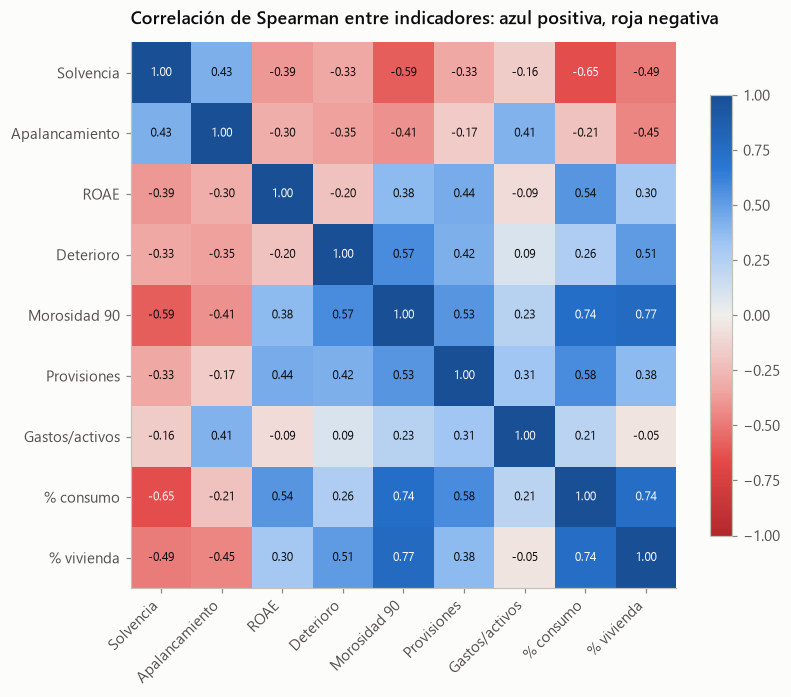

In [4]:
correlacion = bancos[["solvencia", "apalancamiento", "roae", "deterioro", "morosidad_90", "provisiones",
                      "gastos_activos", "participacion_consumo", "participacion_vivienda"]].corr(method="spearman")
etiquetas = ["Solvencia", "Apalancamiento", "ROAE", "Deterioro", "Morosidad 90", "Provisiones", "Gastos/activos",
             "% consumo", "% vivienda"]
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(correlacion, cmap=DIVERGENTE, vmin=-1, vmax=1)
ax.set_xticks(range(len(etiquetas)), etiquetas, rotation=45, ha="right")
ax.set_yticks(range(len(etiquetas)), etiquetas)
for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        valor = correlacion.iloc[i, j]
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(valor) > 0.6 else "#0b0b0b")
ax.grid(False)
ax.set_title("Correlación de Spearman entre indicadores: azul positiva, roja negativa")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

Se usa la correlación de Spearman, basada en rangos, porque las sucursales extranjeras tienen valores extremos que distorsionarían la de Pearson.

**Lectura.**

- **Los indicadores de riesgo de crédito se superponen.** La morosidad de 90 días se asocia al deterioro y, sobre todo, al peso de la cartera de personas, tanto de consumo como de vivienda.
- **Más capital, menos crédito a personas.** La solvencia tiene correlación negativa con la participación de consumo y de vivienda. Los bancos que prestan poco a personas son los que tienen más capital.
- **Consumo y vivienda van juntos.** Los bancos que hacen banca de personas suelen ofrecer ambos productos, así que esas dos variables no son independientes.

Incluir variables que repiten información daría más peso a esas dimensiones en el clustering. Por eso se elige una variable por dimensión.

## 5. Preparación de las variables

Se elige una variable por cada dimensión económica:

| Dimensión | Variable | Transformación |
|---|---|---|
| Capital | solvencia | logaritmo, por los valores extremos de las sucursales extranjeras |
| Rentabilidad | ROAE | ninguna |
| Riesgo de crédito | deterioro | ninguna |
| Eficiencia | gastos sobre activos | ninguna |
| Modelo de negocio | participación de consumo y de vivienda | ninguna |
| Tamaño | colocaciones totales | logaritmo |

Después todas se estandarizan para que tengan media cero y desviación uno.

In [5]:
variables = pd.DataFrame({
    "log_solvencia": np.log(bancos["solvencia"]),
    "roae": bancos["roae"],
    "deterioro": bancos["deterioro"],
    "gastos_activos": bancos["gastos_activos"],
    "participacion_consumo": bancos["participacion_consumo"],
    "participacion_vivienda": bancos["participacion_vivienda"],
    "log_colocaciones": np.log(bancos["colocaciones"]),
})
X = StandardScaler().fit_transform(variables)
print(f"Matriz de {X.shape[0]} bancos y {X.shape[1]} variables estandarizadas")

Matriz de 17 bancos y 7 variables estandarizadas


## 6. ¿Cuántos grupos?

El coeficiente de silueta mide qué tan cerca está cada banco de su propio grupo frente al grupo vecino. Va de -1 a 1, y valores más altos indican grupos mejor separados.

In [6]:
arbol = linkage(X, method="ward")
silueta = {}
for k in range(2, 7):
    etiquetas_km = KMeans(n_clusters=k, n_init=100, random_state=0).fit_predict(X)
    etiquetas_ward = fcluster(arbol, k, criterion="maxclust")
    silueta[k] = {"k-means": silhouette_score(X, etiquetas_km), "Ward": silhouette_score(X, etiquetas_ward)}
silueta = pd.DataFrame(silueta).T
silueta.index.name = "grupos"
silueta

,k-means,Ward
grupos,,
2,0.33,0.33
3,0.36,0.35
4,0.29,0.30
5,0.27,0.27
6,0.28,0.28


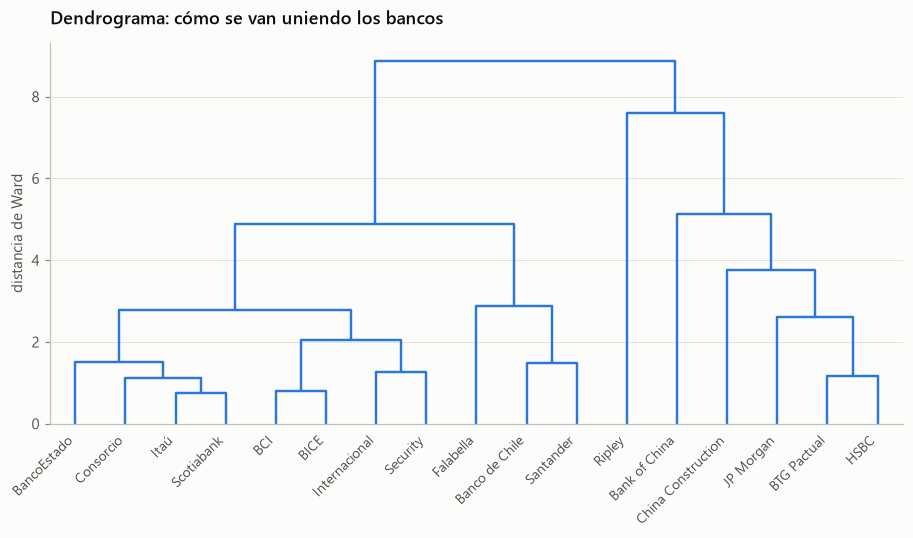

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
dendrogram(arbol, labels=list(variables.index), ax=ax, color_threshold=0, above_threshold_color=COLORES[0],
           leaf_rotation=45, leaf_font_size=9)
ax.set_ylabel("distancia de Ward")
ax.set_title("Dendrograma: cómo se van uniendo los bancos")
ax.grid(axis="x", visible=False)
plt.setp(ax.get_xticklabels(), ha="right")
plt.show()

Tres grupos maximizan la silueta con k-means. El valor, cercano a 0,36, indica una estructura moderada: hay grupos reales, pero con bancos en la frontera. Es esperable con solo 16 observaciones.

## 7. Los tres grupos

In [8]:
modelo = KMeans(n_clusters=3, n_init=100, random_state=0).fit(X)
grupo_numero = pd.Series(modelo.labels_, index=variables.index)

# Nombre de cada grupo según su perfil: el de mayor consumo y el de mayor solvencia.
perfil_bruto = bancos[["participacion_consumo", "solvencia"]].groupby(grupo_numero).median()
id_consumo = perfil_bruto["participacion_consumo"].idxmax()
id_mayorista = perfil_bruto["solvencia"].idxmax()
NOMBRE_GRUPO = {id_consumo: "Banca de consumo", id_mayorista: "Banca mayorista extranjera"}
NOMBRE_GRUPO.update({g: "Banca universal" for g in range(3) if g not in NOMBRE_GRUPO})
grupo = grupo_numero.map(NOMBRE_GRUPO).rename("grupo")

ORDEN_GRUPOS = ["Banca universal", "Banca de consumo", "Banca mayorista extranjera"]
COLOR_GRUPO = dict(zip(ORDEN_GRUPOS, COLORES[:3]))
for nombre in ORDEN_GRUPOS:
    print(f"{nombre}: {', '.join(grupo.index[grupo == nombre])}")

Banca universal: Banco de Chile, BCI, Consorcio, BancoEstado, BICE, Internacional, Itaú, Santander, Scotiabank, Security
Banca de consumo: Falabella, Ripley
Banca mayorista extranjera: BTG Pactual, Bank of China, China Construction, HSBC, JP Morgan


In [9]:
perfil = bancos[columnas_tabla + ["colocaciones"]].groupby(grupo).median().loc[ORDEN_GRUPOS]
perfil["bancos"] = grupo.value_counts()
perfil["% del crédito del sistema"] = 100 * bancos["colocaciones"].groupby(grupo).sum() / bancos["colocaciones"].sum()
perfil.drop(columns="colocaciones").T

grupo,Banca universal,Banca de consumo,Banca mayorista extranjera
solvencia,16.79,16.40,50.74
apalancamiento,7.89,13.78,27.57
roae,13.04,19.39,8.29
deterioro,6.62,5.21,0.45
morosidad_90,2.30,3.29,0.00
provisiones,3.12,8.67,1.71
gastos_activos,1.85,7.96,1.82
participacion_consumo,7.73,69.82,0.00
participacion_vivienda,34.78,24.40,0.00
bancos,10.00,2.00,5.00


### Mapa de los bancos en dos dimensiones

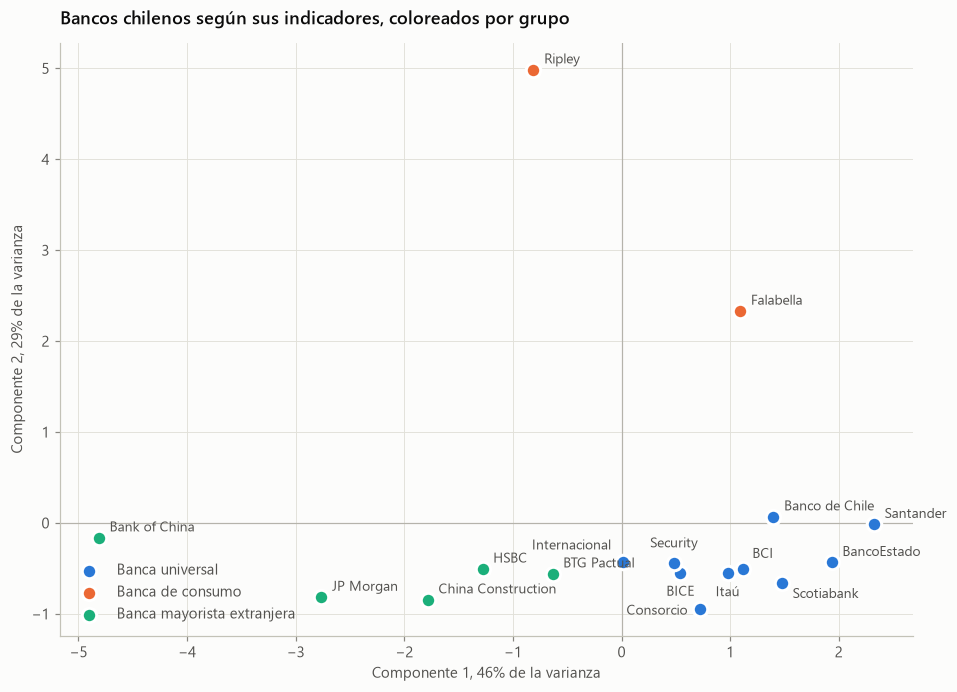

,Componente 1,Componente 2
log_solvencia,-0.47,-0.11
roae,0.34,0.25
deterioro,0.37,0.03
gastos_activos,-0.16,0.65
participacion_consumo,0.07,0.69
participacion_vivienda,0.47,-0.00
log_colocaciones,0.52,-0.18


In [10]:
pca = PCA(n_components=2).fit(X)
coordenadas = pd.DataFrame(pca.transform(X), index=variables.index, columns=["CP1", "CP2"])
varianza = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
for nombre in ORDEN_GRUPOS:
    puntos = coordenadas[grupo == nombre]
    ax.scatter(puntos["CP1"], puntos["CP2"], s=90, color=COLOR_GRUPO[nombre], edgecolor="white", linewidth=2,
               label=nombre, zorder=3)
# Posición de las etiquetas que quedarían superpuestas en la zona de la banca universal.
POSICION = {"Internacional": (-8, 8, "right"), "Security": (0, 10, "center"), "BICE": (0, -15, "center"),
            "Itaú": (0, -15, "center"), "BCI": (6, 7, "left"), "Scotiabank": (7, -10, "left"), "Consorcio": (-8, -4, "right")}
for banco, fila in coordenadas.iterrows():
    dx, dy, alineacion = POSICION.get(banco, (7, 4, "left"))
    ax.annotate(banco, (fila["CP1"], fila["CP2"]), xytext=(dx, dy), textcoords="offset points", fontsize=9,
                ha=alineacion, color=TINTA_SECUNDARIA)

ax.axhline(0, color=NEUTRO, linewidth=0.8)
ax.axvline(0, color=NEUTRO, linewidth=0.8)
ax.set_xlabel(f"Componente 1, {varianza[0]:.0%} de la varianza")
ax.set_ylabel(f"Componente 2, {varianza[1]:.0%} de la varianza")
ax.set_title("Bancos chilenos según sus indicadores, coloreados por grupo")
ax.legend(loc="lower left")
fig.savefig(FIGURAS / "mapa_bancos.png", bbox_inches="tight")
plt.show()

cargas = pd.DataFrame(pca.components_.T, index=variables.columns, columns=["Componente 1", "Componente 2"])
cargas

**Lectura de los ejes.**

- **El primer componente** separa a los bancos grandes, con crédito hipotecario y más cartera deteriorada, de los pequeños con mucho capital. Va de la banca mayorista extranjera, a la izquierda, a la banca universal, a la derecha.
- **El segundo componente** es el modelo de negocio minorista: más crédito de consumo, más gastos operacionales. Ahí se separa la banca de consumo.

**Perfil de cada grupo.**

- **Banca universal.** Concentra casi todo el crédito del sistema. Combina cartera comercial, hipotecaria y de consumo, con solvencia cercana al promedio del sistema.
- **Banca de consumo.** Tiene la mayor proporción de crédito de consumo, los gastos operacionales más altos y más provisiones. Es un modelo de alto margen y alto costo.
- **Banca mayorista extranjera.** Casi no presta a personas, tiene carteras de crédito pequeñas y capital muy holgado. Su baja morosidad refleja el tipo de cliente, grandes empresas, más que una mejor gestión del riesgo.

## 8. ¿Qué tan robustos son los grupos?

In [11]:
grupos_ward = pd.Series(fcluster(arbol, 3, criterion="maxclust"), index=variables.index)
coincidencia = adjusted_rand_score(grupo_numero, grupos_ward)
print(f"Índice de Rand ajustado entre k-means y Ward: {coincidencia:.2f} (1 es coincidencia total)")

comparacion = pd.DataFrame({"k-means": grupo, "Ward": grupos_ward})
ward_a_nombre = comparacion.groupby("Ward")["k-means"].agg(lambda s: s.mode().iloc[0])
comparacion["Ward"] = comparacion["Ward"].map(ward_a_nombre)
distintos = comparacion[comparacion["k-means"] != comparacion["Ward"]]
print("Bancos asignados distinto por los dos métodos:")
print(distintos.to_string() if len(distintos) else "ninguno")

Índice de Rand ajustado entre k-means y Ward: 0.84 (1 es coincidencia total)
Bancos asignados distinto por los dos métodos:
                    k-means             Ward
banco                                       
Falabella  Banca de consumo  Banca universal


Los dos métodos coinciden en casi todos los bancos. La diferencia está en Falabella: k-means la pone junto a Ripley en la banca de consumo, mientras Ward la deja en la banca universal. Tiene sentido, porque Falabella tiene la mitad de su cartera en consumo, pero también una cartera hipotecaria relevante. Es un banco híbrido.

Con cinco grupos, ambos métodos separan además a los bancos universales más rentables, Banco de Chile y Santander, junto con Falabella, del resto de la banca universal.

## 9. Evolución de los grupos en el tiempo

Con los grupos del corte actual se revisa cómo evolucionaron la rentabilidad, el riesgo de crédito y la solvencia desde 2019.

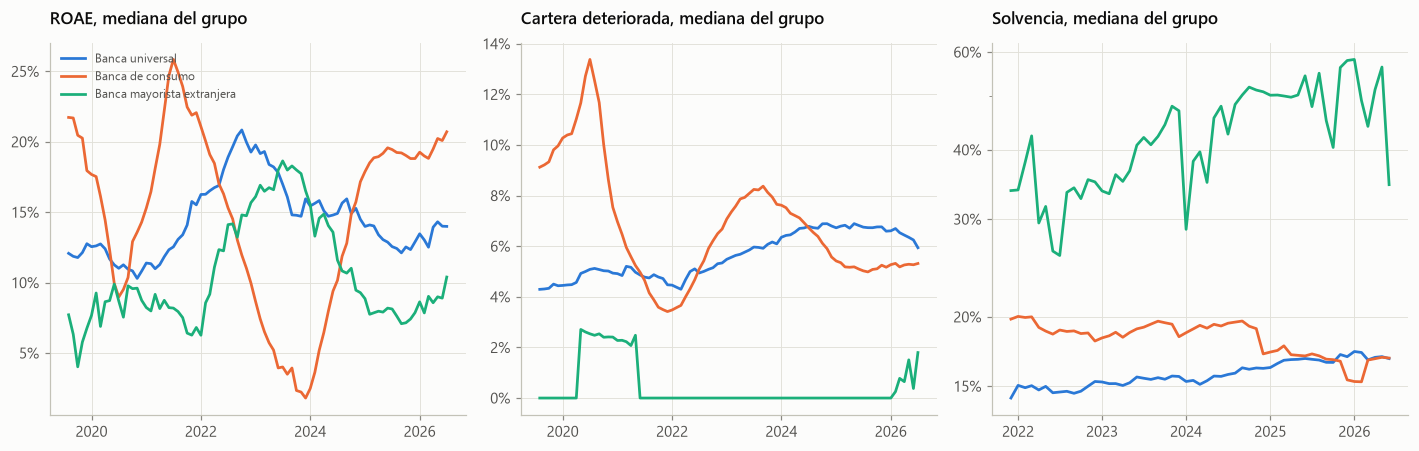

In [12]:
def evolucion(indicador):
    tabla = series[indicador].copy()
    tabla["nombre_banco"] = tabla["banco"].map(NOMBRES)
    tabla = tabla[tabla["nombre_banco"].isin(grupo.index)]
    tabla["grupo"] = tabla["nombre_banco"].map(grupo)
    return tabla.groupby(["fecha", "grupo"])["valor"].median().unstack()[ORDEN_GRUPOS]

fig, ejes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (indicador, titulo) in zip(ejes, [("roae", "ROAE, mediana del grupo"),
                                         ("deterioro", "Cartera deteriorada, mediana del grupo"),
                                         ("solvencia", "Solvencia, mediana del grupo")]):
    tabla = evolucion(indicador)
    for nombre in ORDEN_GRUPOS:
        ax.plot(tabla.index, tabla[nombre], color=COLOR_GRUPO[nombre], linewidth=1.8, label=nombre)
    ax.set_title(titulo, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ejes[2].set_yscale("log")
ejes[2].set_yticks([15, 20, 30, 40, 60])
ejes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ejes[2].yaxis.set_minor_formatter(plt.NullFormatter())
import matplotlib.dates as mdates
for ax in ejes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2 if ax is not ejes[2] else 1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ejes[0].legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURAS / "evolucion_grupos.png", bbox_inches="tight")
plt.show()

**Lectura.**

- **Rentabilidad.** La banca de consumo tiene la rentabilidad más volátil: pasó de más de 25% en 2021 a menos de 3% a fines de 2023, y luego se recuperó. Sus resultados dependen del ciclo de crédito a personas.
- **Riesgo de crédito.** En la banca de consumo, la cartera deteriorada llegó a 13% en 2020 y cayó con fuerza en 2021, coincidiendo con un período de alta liquidez de los hogares por los retiros de fondos de pensiones y las transferencias fiscales. En la banca universal subió de forma sostenida desde 2022, en línea con el alza de tasas y la desaceleración que se vio en el bloque de series de tiempo.
- **Solvencia.** Los indicadores de Basilea III se publican desde diciembre de 2021. La solvencia de la banca universal subió gradualmente, en línea con la implementación de los colchones de capital. La escala logarítmica permite ver juntos a los tres grupos.

## 10. Conclusiones

1. **El sistema bancario chileno tiene tres modelos de negocio claros.** La banca universal, la de consumo y la mayorista extranjera se distinguen sobre todo por el tipo de crédito y el nivel de capital.
2. **La concentración es alta.** La banca universal reúne casi todo el crédito del sistema, así que el riesgo sistémico depende de ese grupo.
3. **Todos los bancos cumplen holgadamente el mínimo de capital.** La diferencia entre grupos refleja el modelo de negocio, no problemas de solvencia.
4. **Los grupos son útiles, pero no rígidos.** Falabella muestra que hay bancos híbridos, y la silueta moderada indica que las fronteras entre grupos no son nítidas.

## 11. Limitaciones y extensiones

- **Pocas observaciones.** Con 17 bancos, cualquier clustering es sensible a la elección de variables. Por eso se contrastaron dos métodos y se reportan los bancos que cambian de grupo.
- **Promedios de doce meses.** El análisis es una foto reciente. Repetirlo año a año mostraría si los bancos cambian de grupo.
- **Sin indicadores de liquidez.** La API no publica por banco el LCR ni el NSFR de Basilea III, que completarían la mirada de riesgo.
- **Extensión natural.** Estos grupos sirven como punto de partida para pruebas de estrés por segmento, que es uno de los proyectos planificados en repositorios independientes.